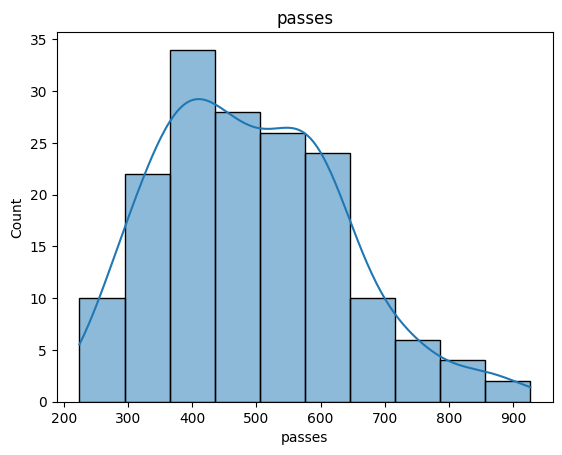

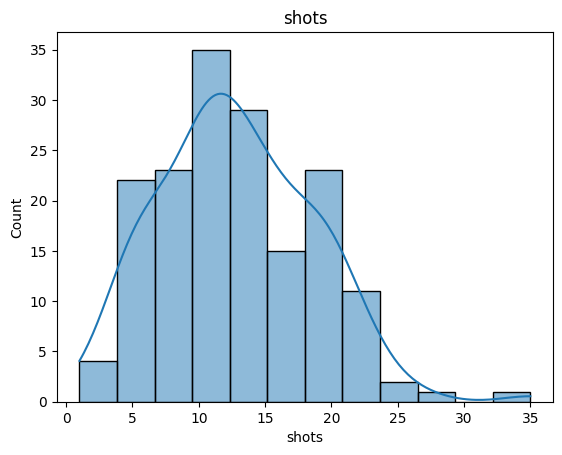

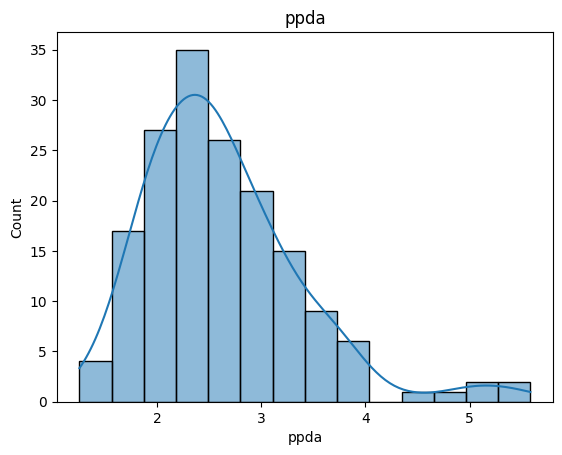

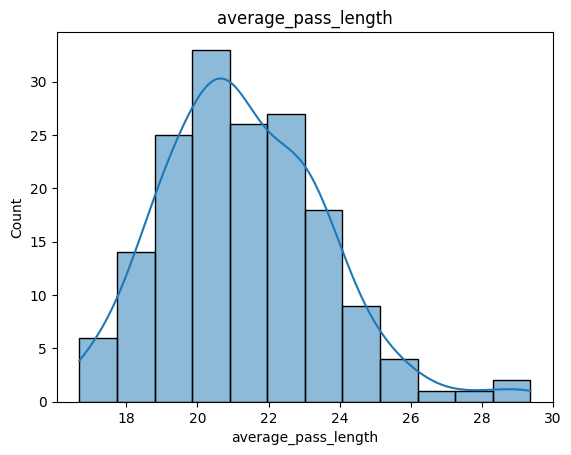

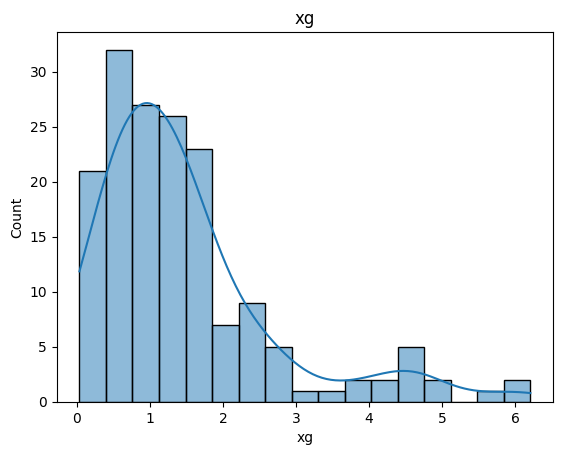

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

features = ["passes", "shots", "ppda", "average_pass_length", "xg"]

matchwise_stats = pd.read_csv(r"../data/matchwise_stats.csv")

for col in features:
    sns.histplot(matchwise_stats[col], kde=True)
    plt.title(col)
    plt.show()

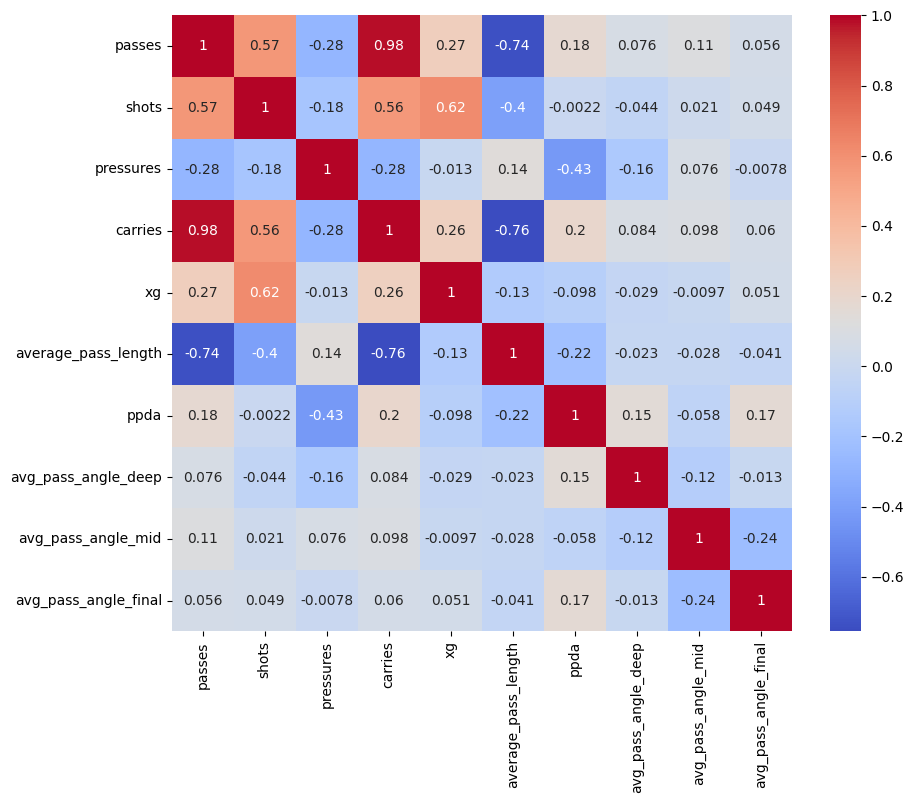

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(matchwise_stats.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

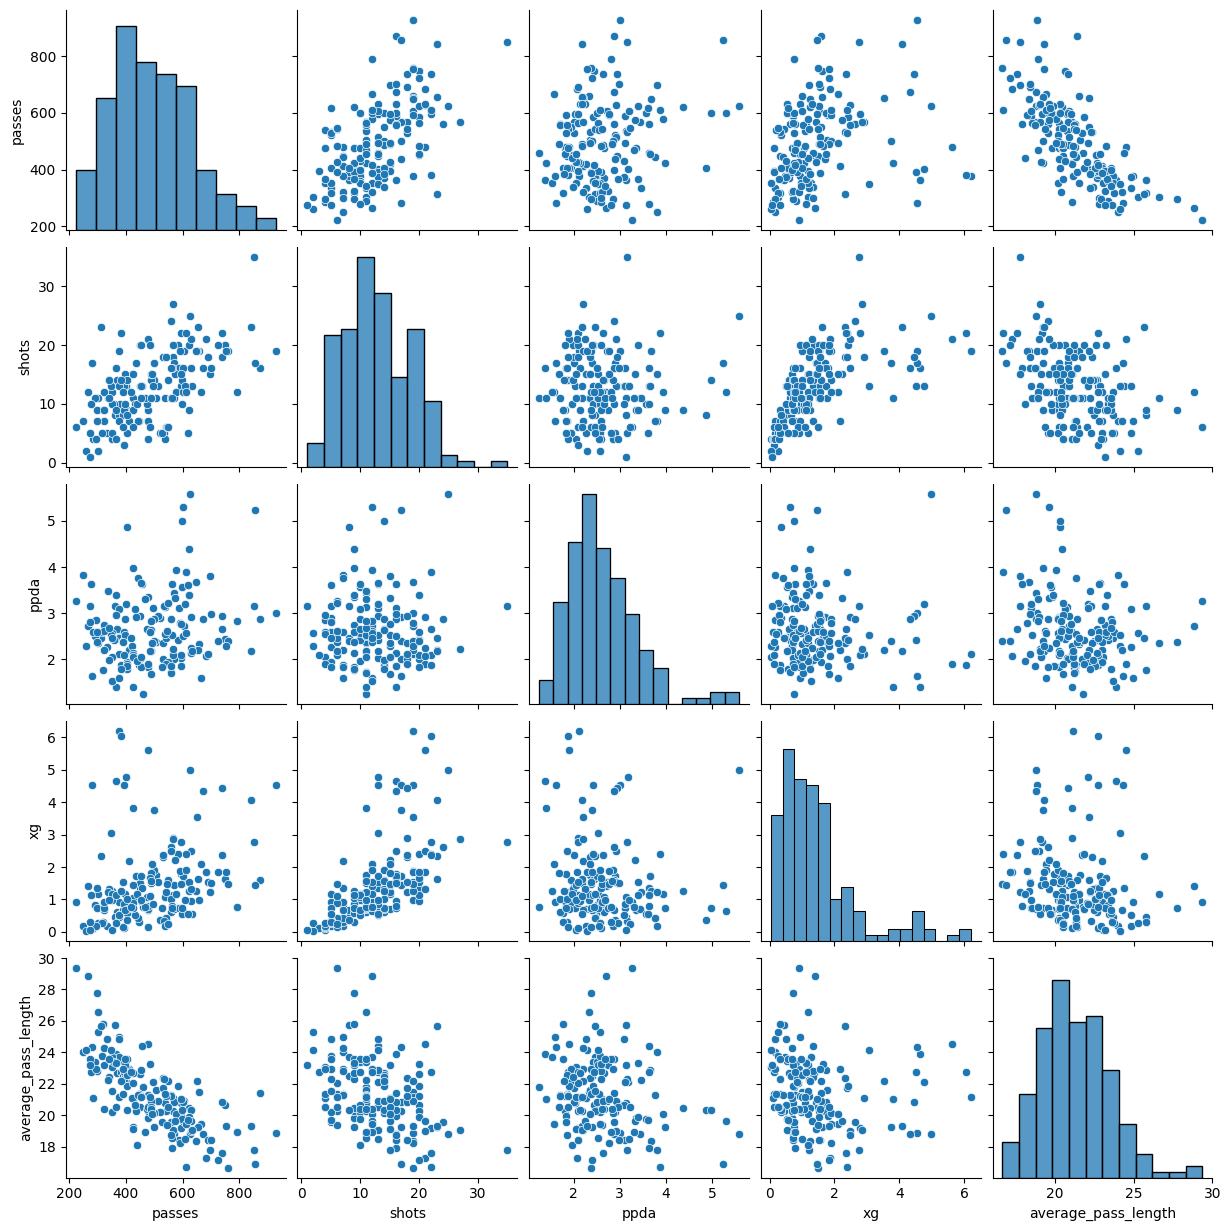

In [4]:
sns.pairplot(matchwise_stats[[
    "passes", "shots", "ppda", "xg", "average_pass_length"
]])
plt.show()

We see high correlation between Passes and Carries, XG and shots so we make new features

- `xg_per_shot` = `xg/shots`
- `carries_per_pass` = `carries/passes`

In [5]:
def make_new_features(df):
    df['xg_per_shot'] = df["xg"]/df["shots"]
    df["carries_per_pass"] = df["carries"]/df["passes"]

    new_df = df.drop(columns = ["xg", "carries", "pressures"])
    return new_df

proc_matchwise = make_new_features(matchwise_stats)
proc_matchwise

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,team,xg_per_shot,carries_per_pass
0,537,11,20.786734,3.128655,-0.042155,-0.046114,-0.023094,Argentina,0.098427,0.769088
1,659,19,21.512906,2.338624,-0.034995,-0.128787,1.816389,Colombia,0.052009,0.799697
2,378,19,21.140958,2.108844,-0.107044,0.033943,-0.629554,Canada,0.326595,0.759259
3,365,16,23.869265,1.385417,-0.124896,0.032662,0.152638,Uruguay,0.290652,0.794521
4,460,11,21.812680,1.252688,-0.147674,-0.093207,-0.566419,Uruguay,0.068597,0.791304
...,...,...,...,...,...,...,...,...,...,...
161,558,16,18.769656,1.855263,0.007978,0.261361,-2.335340,Croatia,0.155131,0.820789
162,484,6,21.134856,2.184971,-0.063716,-0.292197,1.049329,Hungary,0.183808,0.679752
163,492,15,20.101638,2.358824,0.196319,-0.057198,-1.941647,Switzerland,0.139718,0.798780
164,724,20,17.179018,2.403846,-0.091657,0.181765,-2.794614,Germany,0.092232,0.806630


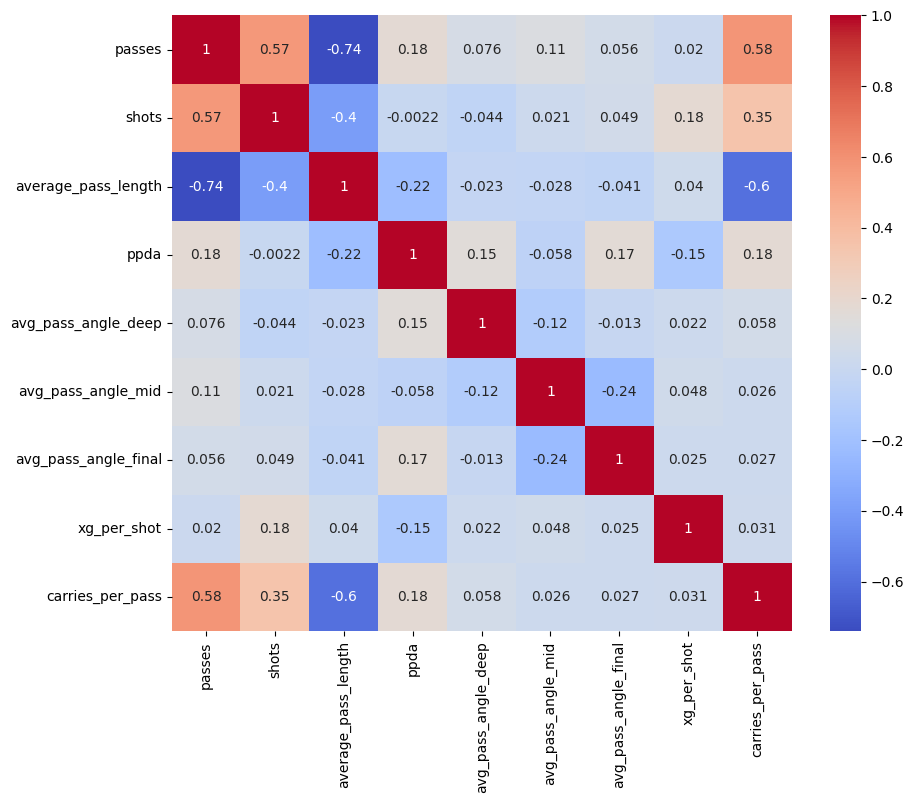

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(proc_matchwise.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [7]:
teamwise_avg = pd.read_csv(r"../data/team_stats_raw.csv")

teamwise_avg_proc = make_new_features(teamwise_avg)
teamwise_avg_proc

,team,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,xg_per_shot,carries_per_pass
0,Albania,392.666667,10.666667,21.152318,3.315112,-0.079853,-0.161259,1.125253,0.068238,0.820883
1,Argentina,559.666667,14.666667,20.898589,2.424673,0.003169,-0.017089,-1.030759,0.182316,0.815962
2,Austria,517.500000,12.500000,20.446254,2.142054,0.142069,0.010456,-0.161990,0.122316,0.802899
3,Belgium,551.750000,13.250000,20.983358,3.320037,-0.195753,-0.129669,0.369445,0.082606,0.855007
4,Bolivia,408.000000,5.666667,21.921076,2.087439,-0.058614,-0.425858,-0.465007,0.058136,0.772876
5,Brazil,530.000000,13.750000,20.577336,2.026312,0.150315,-0.169108,-1.144768,0.172447,0.827830
6,Canada,412.000000,12.333333,21.194503,2.279355,0.027886,-0.112432,-0.386921,0.209756,0.771036
7,Chile,439.000000,7.333333,23.249089,2.314058,-0.075030,-0.091201,0.189099,0.073171,0.793470
8,Colombia,492.000000,13.166667,22.336315,2.272290,-0.010857,0.095794,0.219009,0.118580,0.762534
9,Costa Rica,300.333333,3.000000,24.756273,2.371913,-0.082550,0.269005,0.531436,0.052676,0.748058


In [8]:
proc_matchwise.to_csv(r"../data/matchwise_processed.csv", index=False)
teamwise_avg_proc.to_csv(r"../data/team_stats_processed.csv", index=False)